In [4]:
import freesasa

In [54]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from Bio import SeqIO, PDB

import glob

In [6]:
metrics_df = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_full.tsv.gz', sep='\t')
filtered = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t')

In [7]:
pdbs = glob.glob('./../data/processed_structures/*.pdb')

In [8]:
pdbs[:5]

['./../data/processed_structures/GB_GCA_001054945.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000717275.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_001187505.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000376885.1_A_processed.pdb',
 './../data/processed_structures/GB_GCA_000411155.1_A_processed.pdb']

In [94]:
def compute_delta_sasa_freesasa(pdb_file):
    """
    Compute delta SASA using FreeSASA
    """
    # Load structure
    structure = freesasa.Structure(pdb_file)
    
    # Calculate SASA for folded state
    folded_result = freesasa.calc(structure)
    
    # Get per-residue SASA
    classifier = freesasa.Classifier()
    folded_sasa_by_residue = {}
    
    for i in range(structure.nAtoms()):
        atom = structure.atomName(i)
        residue_number = structure.residueNumber(i)
        residue_name = structure.residueName(i)
        
        if residue_number not in folded_sasa_by_residue:
            folded_sasa_by_residue[residue_number] = {
                'name': residue_name,
                'sasa': 0.0
            }
        
        folded_sasa_by_residue[residue_number]['sasa'] += folded_result.atomArea(i)
    
    # Reference values (Tien et al. 2013, or Miller et al. 1987)
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }
    
    # Calculate delta SASA
    delta_sasa = {}
    for res_num, res_data in folded_sasa_by_residue.items():
        res_name = res_data['name']
        if res_name in reference_sasa:
            delta_sasa[res_num] = reference_sasa[res_name] - res_data['sasa']
    
    return delta_sasa


def compute_residue_sasa_and_delta(pdb_file):
    """
    Compute per-residue solvent-accessible surface area (SASA) and ΔSASA
    using FreeSASA.

    Parameters
    ----------
    pdb_file : str
        Path to PDB file.

    Returns
    -------
    dict
        Dictionary mapping residue number → {
            'resname': str,
            'sasa': float,
            'delta_sasa': float
        }
    """

    # Load structure and compute SASA
    structure = freesasa.Structure(pdb_file)
    result = freesasa.calc(structure)

    # Reference SASA values for fully exposed residues (Å²)
    # Source: Tien et al. 2013 or Miller et al. 1987
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }

    # Aggregate per-residue SASA
    sasa_by_residue = {}
    for i in range(structure.nAtoms()):
        res_num = structure.residueNumber(i)
        res_name = structure.residueName(i)

        if res_num not in sasa_by_residue:
            sasa_by_residue[res_num] = {'resname': res_name, 'sasa': 0.0}

        sasa_by_residue[res_num]['sasa'] += result.atomArea(i)

    # Compute ΔSASA (difference from reference)
    for res_num, res_data in sasa_by_residue.items():
        res_name = res_data['resname']
        sasa = res_data['sasa']
        if res_name in reference_sasa:
            delta = reference_sasa[res_name] - sasa
        else:
            delta = None  # unknown residue type
        res_data['delta_sasa'] = delta
    
    return sasa_by_residue

def compute_normalized_delta_sasa(pdb_file):
    """
    Compute normalized delta SASA (0 = fully buried, 1 = fully exposed)
    """
    delta_sasa = compute_delta_sasa_freesasa(pdb_file)
    
    # Reference SASA values
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }
    
    normalized_delta_sasa = {}
    for res_num, delta_val in delta_sasa.items():
        # Need to get residue name for normalization
        # This is simplified - you'd need to get actual residue name
        res_name = 'ALA'  # placeholder
        if res_name in reference_sasa:
            normalized_delta_sasa[res_num] = delta_val / reference_sasa[res_name]
    
    return normalized_delta_sasa

## outline
Compute a deltaSASA for the residues in each protein and see whether the average change of the residues is correlated with higher or lower thermostability

In [17]:
test_dataset = filtered.groupby('temp').apply(lambda x: x.sample(np.min([100, len(x)]), replace=False))

In [18]:
df_list = []
for p in pdbs:
    uid =  p.split('/')[-1].split('_A_')[0]
    if uid in test_dataset['uid'].unique():
        df_list.append(pd.Series(compute_normalized_delta_sasa(p), name=uid))

test_df = pd.concat(df_list, axis=1)
test_df.head()

,GB_GCA_001749745.1,RS_GCF_000427905.1,RS_GCF_000379025.1,RS_GCF_000023825.1,RS_GCF_000213255.1,RS_GCF_000242915.1,RS_GCF_000517025.1,RS_GCF_001418005.1,RS_GCF_000014725.1,RS_GCF_000178835.2,...,RS_GCF_902459735.1,RS_GCF_900536025.1,RS_GCF_900566055.1,RS_GCF_902459765.1,RS_GCF_900566075.1,RS_GCF_902459805.1,RS_GCF_902499555.1,RS_GCF_900606115.1,RS_GCF_902499125.1,RS_GCF_902804485.1
1,1.121268,NaN,1.253346,0.991487,1.155460,1.139857,1.115837,1.268971,1.169207,1.283976,...,1.314481,1.301405,1.284606,1.299036,1.245111,1.283554,0.797266,1.275181,1.314428,0.860278
2,1.295136,0.518896,1.431592,1.181297,1.329010,1.558389,1.416331,1.786367,1.454736,1.795096,...,1.443717,1.551883,1.826351,1.463084,1.814119,1.467270,1.011680,1.549162,1.448148,1.182927
3,1.540414,1.147235,1.558140,1.511628,1.527132,1.527132,1.556067,1.557991,1.522914,1.558140,...,1.558140,1.345457,1.348837,1.558140,1.348743,1.558140,1.511628,1.558140,1.558140,1.511628
4,1.348837,2.035079,1.527132,1.839351,1.348696,1.527132,1.348837,1.527132,1.520357,1.527132,...,1.503874,1.527132,1.347329,1.504616,1.346843,1.527132,1.518531,1.522790,1.519535,1.527132
5,1.842610,1.537511,1.547718,1.342239,1.548831,1.537654,1.543362,1.551198,1.533423,1.541451,...,1.541247,1.543162,1.542032,1.529617,1.543653,1.541362,1.340346,1.547677,1.542432,1.348113


<Axes: xlabel='None', ylabel='temp'>

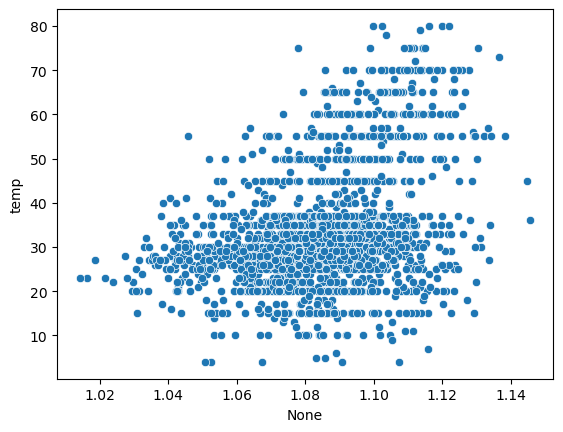

In [19]:
sns.scatterplot(x=test_df.mean(), y=test_dataset.set_index('uid')['temp'])

In [20]:
with open('./../data/20240122_all_adks_filtered_nogap.afa', 'r') as handle:
    lines = [pd.Series(index=range(len(r.seq)), data=[i for i in str(r.seq)], name=r.id) for r in SeqIO.parse(handle, 'fasta')]

aln_df = pd.concat(lines, axis=1).T

def translate_with_gaps(nuc_seq):
    return [
        str(Seq(codon).translate()) if '-' not in codon and len(codon) == 3 else '-'
        for codon in [nuc_seq[i:i+3] for i in range(0, len(nuc_seq), 3)]
    ]

# aln_df = pd.concat([aln_df, anc_trim_df]).fillna('-')

aln_df.head()

aln_df.index = [s.split('|')[1] for s in aln_df.index]

In [28]:
# Convert to numpy for speed
sasa_array = test_df.T.values

# Handle NaN values by filling with column means
col_means = np.nanmean(sasa_array, axis=0)
sasa_filled = np.where(np.isnan(sasa_array), col_means, sasa_array)

window_averages = uniform_filter1d(
    sasa_filled, 
    size=39, 
    axis=1, 
    mode='constant'
)

In [31]:
# sns.histplot(
pd.DataFrame(data=window_averages, index=test_df.T.index).apply(lambda x: pearsonr(x, test_dataset.set_index('uid')['temp'].reindex(index=x.index))[0], axis=0).idxmax()
            # )

192

<Axes: xlabel='192', ylabel='temp'>

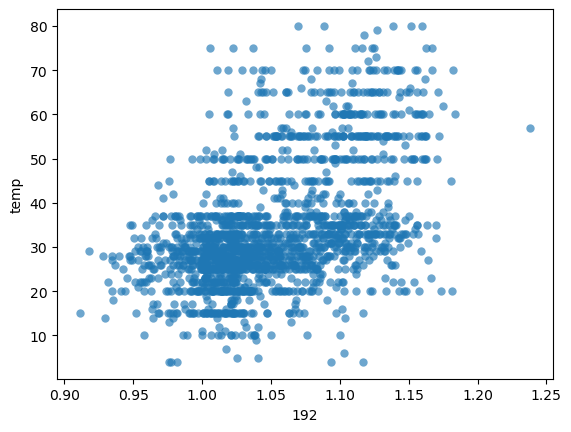

In [37]:
sns.scatterplot(x=pd.DataFrame(data=window_averages, index=test_df.T.index).loc[:, 192],
                y= test_dataset.set_index('uid')['temp'], linewidth=0, alpha=0.65)

In [50]:
sasa_filled

array([[1.25334636, 1.43159196, 1.55813953, ..., 1.13441848, 1.45457182,
        0.02099583],
       [1.3358836 , 1.76934596, 1.52713178, ..., 1.13441848, 1.45457182,
        0.02099583],
       [1.15546046, 1.32901012, 1.52713178, ..., 1.13441848, 1.45457182,
        0.02099583],
       ...,
       [1.28355352, 1.46726975, 1.55813953, ..., 1.13441848, 1.45457182,
        0.02099583],
       [0.79726611, 1.01167984, 1.51162791, ..., 1.13441848, 1.45457182,
        0.02099583],
       [0.86027754, 1.18292725, 1.51162791, ..., 1.13441848, 1.45457182,
        0.02099583]])

In [32]:

from scipy.stats import pearsonr, spearmanr
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

class SASAWindowAnalyzer:
    """
    Efficiently analyze SASA windows for correlation with traits
    """
    
    def __init__(self, sasa_df: pd.DataFrame, traits: pd.Series, 
                 max_window_size: int = 50, min_window_size: int = 3):
        """
        Initialize analyzer
        
        Parameters:
        -----------
        sasa_df : pd.DataFrame
            DataFrame with proteins as rows, residue positions as columns
            Contains delta SASA values
        traits : pd.Series
            Series with protein names as index, trait values as values
        max_window_size : int
            Maximum window size to test
        min_window_size : int
            Minimum window size to test
        """
        self.sasa_df = sasa_df
        self.traits = traits
        self.max_window_size = max_window_size
        self.min_window_size = min_window_size
        
        # Align data
        common_proteins = list(set(sasa_df.index) & set(traits.index))
        self.sasa_df = sasa_df.loc[common_proteins]
        self.traits = traits.loc[common_proteins]
        
        # Results storage
        self.results = []
        self.best_windows = {}
        
    def compute_sliding_windows_vectorized(self, window_size: int) -> np.ndarray:
        """
        Compute all sliding window averages efficiently using convolution
        
        Parameters:
        -----------
        window_size : int
            Size of sliding window
            
        Returns:
        --------
        np.ndarray
            Array of shape (n_proteins, n_positions - window_size + 1)
            Each element is the average SASA for that window
        """
        # Convert to numpy for speed
        sasa_array = self.sasa_df.values
        
        # Handle NaN values by filling with column means
        col_means = np.nanmean(sasa_array, axis=0)
        sasa_filled = np.where(np.isnan(sasa_array), col_means, sasa_array)
        
        # Use uniform_filter1d for efficient sliding window computation
        # This is equivalent to convolution but faster
        window_averages = uniform_filter1d(
            sasa_filled, 
            size=window_size, 
            axis=1, 
            mode='constant'
        )
        
        # Trim to valid windows only
        valid_positions = sasa_filled.shape[1] - window_size + 1
        return window_averages[:, :valid_positions]
    
    def analyze_window_size(self, window_size: int, correlation_method: str = 'pearson') -> Dict:
        """
        Analyze all windows of a given size
        
        Parameters:
        -----------
        window_size : int
            Size of window to analyze
        correlation_method : str
            'pearson' or 'spearman'
            
        Returns:
        --------
        Dict containing results for this window size
        """
        # Get all window averages
        window_averages = self.compute_sliding_windows_vectorized(window_size)
        
        # Compute correlations for each window position
        n_windows = window_averages.shape[1]
        correlations = np.zeros(n_windows)
        p_values = np.zeros(n_windows)
        
        trait_values = self.traits.values
        
        for i in range(n_windows):
            window_sasa = window_averages[:, i]
            
            # Remove any remaining NaN values
            valid_mask = ~np.isnan(window_sasa) & ~np.isnan(trait_values)
            
            if np.sum(valid_mask) > 3:  # Need at least 4 points for correlation
                if correlation_method == 'pearson':
                    corr, p_val = pearsonr(window_sasa[valid_mask], trait_values[valid_mask])
                else:
                    corr, p_val = spearmanr(window_sasa[valid_mask], trait_values[valid_mask])
                
                correlations[i] = corr
                p_values[i] = p_val
            else:
                correlations[i] = np.nan
                p_values[i] = np.nan
        
        # Find best window for this size
        abs_correlations = np.abs(correlations)
        best_idx = np.nanargmax(abs_correlations)
        
        return {
            'window_size': window_size,
            'correlations': correlations,
            'p_values': p_values,
            'best_correlation': correlations[best_idx],
            'best_p_value': p_values[best_idx],
            'best_position': best_idx,
            'best_window_range': (best_idx, best_idx + window_size - 1)
        }
    
    def run_full_analysis(self, correlation_method: str = 'pearson', 
                         step_size: int = 1) -> pd.DataFrame:
        """
        Run analysis across all window sizes
        
        Parameters:
        -----------
        correlation_method : str
            'pearson' or 'spearman'
        step_size : int
            Step size for window sizes (1 = test every size)
            
        Returns:
        --------
        pd.DataFrame with results summary
        """
        print(f"Analyzing windows from {self.min_window_size} to {self.max_window_size}")
        
        self.results = []
        
        window_sizes = range(self.min_window_size, self.max_window_size + 1, step_size)
        
        for window_size in tqdm(window_sizes, desc="Window sizes"):
            if window_size > self.sasa_df.shape[1]:
                continue
                
            result = self.analyze_window_size(window_size, correlation_method)
            self.results.append(result)
            
            # Store best windows
            self.best_windows[window_size] = result
        
        # Create summary DataFrame
        summary_data = []
        for result in self.results:
            summary_data.append({
                'window_size': result['window_size'],
                'best_correlation': result['best_correlation'],
                'best_p_value': result['best_p_value'],
                'best_position': result['best_position'],
                'best_start': result['best_window_range'][0],
                'best_end': result['best_window_range'][1]
            })
        
        return pd.DataFrame(summary_data)
    
    def get_top_windows(self, n_top: int = 10) -> pd.DataFrame:
        """
        Get top N windows across all sizes
        
        Parameters:
        -----------
        n_top : int
            Number of top windows to return
            
        Returns:
        --------
        pd.DataFrame with top windows
        """
        all_windows = []
        
        for result in self.results:
            window_size = result['window_size']
            correlations = result['correlations']
            p_values = result['p_values']
            
            for i, (corr, p_val) in enumerate(zip(correlations, p_values)):
                if not np.isnan(corr):
                    all_windows.append({
                        'window_size': window_size,
                        'start_position': i,
                        'end_position': i + window_size - 1,
                        'correlation': corr,
                        'abs_correlation': abs(corr),
                        'p_value': p_val
                    })
        
        df = pd.DataFrame(all_windows)
        return df.nlargest(n_top, 'abs_correlation')
    
    def plot_results(self, figsize: Tuple[int, int] = (15, 10)):
        """
        Plot analysis results
        """
        if not self.results:
            print("No results to plot. Run analysis first.")
            return
        
        fig, axes = plt.subplots(2, 2, figsize=figsize)
        
        # Plot 1: Best correlation vs window size
        window_sizes = [r['window_size'] for r in self.results]
        best_corrs = [r['best_correlation'] for r in self.results]
        
        axes[0, 0].plot(window_sizes, best_corrs, 'bo-')
        axes[0, 0].set_xlabel('Window Size')
        axes[0, 0].set_ylabel('Best Correlation')
        axes[0, 0].set_title('Best Correlation vs Window Size')
        axes[0, 0].grid(True)
        
        # Plot 2: Best position vs window size
        best_positions = [r['best_position'] for r in self.results]
        axes[0, 1].plot(window_sizes, best_positions, 'ro-')
        axes[0, 1].set_xlabel('Window Size')
        axes[0, 1].set_ylabel('Best Position')
        axes[0, 1].set_title('Best Position vs Window Size')
        axes[0, 1].grid(True)
        
        # Plot 3: Heatmap of correlations (for selected window sizes)
        selected_sizes = window_sizes[::max(1, len(window_sizes)//10)]  # Sample ~10 sizes
        heatmap_data = []
        
        for size in selected_sizes:
            result = self.best_windows[size]
            # Pad correlations to same length
            corrs = result['correlations']
            max_len = max(len(r['correlations']) for r in self.results)
            padded_corrs = np.pad(corrs, (0, max_len - len(corrs)), constant_values=np.nan)
            heatmap_data.append(padded_corrs)
        
        if heatmap_data:
            heatmap_array = np.array(heatmap_data)
            im = axes[1, 0].imshow(heatmap_array, aspect='auto', cmap='RdBu_r')
            axes[1, 0].set_xlabel('Position')
            axes[1, 0].set_ylabel('Window Size')
            axes[1, 0].set_title('Correlation Heatmap')
            axes[1, 0].set_yticks(range(len(selected_sizes)))
            axes[1, 0].set_yticklabels(selected_sizes)
            plt.colorbar(im, ax=axes[1, 0])

        for site in [62, 209, 201, 25, 2, 205, 179, 160]:
            axes[1, 0].axvline(site, color='k')
        
        # Plot 4: P-value distribution
        all_p_values = []
        for result in self.results:
            p_vals = result['p_values']
            all_p_values.extend(p_vals[~np.isnan(p_vals)])
        
        if all_p_values:
            axes[1, 1].hist(all_p_values, bins=50, alpha=0.7)
            axes[1, 1].axvline(x=0.05, color='red', linestyle='--', label='p=0.05')
            axes[1, 1].set_xlabel('P-value')
            axes[1, 1].set_ylabel('Frequency')
            axes[1, 1].set_title('P-value Distribution')
            axes[1, 1].legend()
        
        plt.tight_layout()
        plt.show()
    
    def get_window_features(self, top_n: int = 10) -> pd.DataFrame:
        """
        Extract top windows as features for downstream modeling
        
        Parameters:
        -----------
        top_n : int
            Number of top windows to extract as features
            
        Returns:
        --------
        pd.DataFrame with proteins as rows, window features as columns
        """
        top_windows = self.get_top_windows(top_n)
        
        features = []
        feature_names = []
        
        for _, window in top_windows.iterrows():
            window_size = window['window_size']
            start_pos = int(window['start_position'])
            end_pos = int(window['end_position'])
            
            # Compute window averages for this specific window
            window_avg = self.sasa_df.iloc[:, start_pos:end_pos+1].mean(axis=1)
            
            features.append(window_avg)
            feature_names.append(f'window_{start_pos}_{end_pos}_size{window_size}')
        
        feature_df = pd.DataFrame(np.array(features).T, 
                                index=self.sasa_df.index, 
                                columns=feature_names)
        
        return feature_df

# # Example usage
# def example_usage():
#     """
#     Example of how to use the SASAWindowAnalyzer
#     """
#     # Create sample data
#     np.random.seed(42)
#     n_proteins = 100
#     n_residues = 200
    
#     # Generate synthetic SASA data
#     sasa_data = np.random.randn(n_proteins, n_residues)
    
#     # Add some regional patterns
#     sasa_data[:, 50:70] += np.random.randn(n_proteins, 20) * 2  # High variance region
#     sasa_data[:, 120:140] -= 1  # Consistently buried region
    
#     # Create DataFrames
#     protein_names = [f'protein_{i}' for i in range(n_proteins)]
#     sasa_df = pd.DataFrame(sasa_data, index=protein_names)
    
#     # Generate synthetic trait correlated with specific regions
#     trait_values = (sasa_data[:, 55:65].mean(axis=1) + 
#                    sasa_data[:, 125:135].mean(axis=1) + 
#                    np.random.randn(n_proteins) * 0.5)
#     traits = pd.Series(trait_values, index=protein_names)
    
#     # Run analysis
#     analyzer = SASAWindowAnalyzer(sasa_df, traits, max_window_size=30)
#     summary = analyzer.run_full_analysis()
    
#     print("Top 5 window sizes by correlation:")
#     print(summary.nlargest(5, 'best_correlation'))
    
#     print("\nTop 10 windows overall:")
#     top_windows = analyzer.get_top_windows(10)
#     print(top_windows)
    
#     # Plot results
#     analyzer.plot_results()
    
#     # Get features for modeling
#     window_features = analyzer.get_window_features(5)
#     print(f"\nWindow features shape: {window_features.shape}")
#     print(window_features.head())

Analyzing windows from 3 to 50


Window sizes: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 48/48 [00:09<00:00,  5.06it/s]


      window_size  start_position  end_position  correlation  abs_correlation  \
7790           35             190           224     0.490960         0.490960   
8670           39             192           230     0.487307         0.487307   
8012           36             191           226     0.483512         0.483512   
8011           36             190           225     0.482970         0.482970   
7569           34             191           224     0.481532         0.481532   
8887           40             192           231     0.481043         0.481043   
7568           34             190           223     0.480150         0.480150   
8230           37             189           225     0.477882         0.477882   
8452           38             192           229     0.477642         0.477642   
8453           38             193           230     0.476837         0.476837   
8449           38             189           226     0.476711         0.476711   
8231           37           

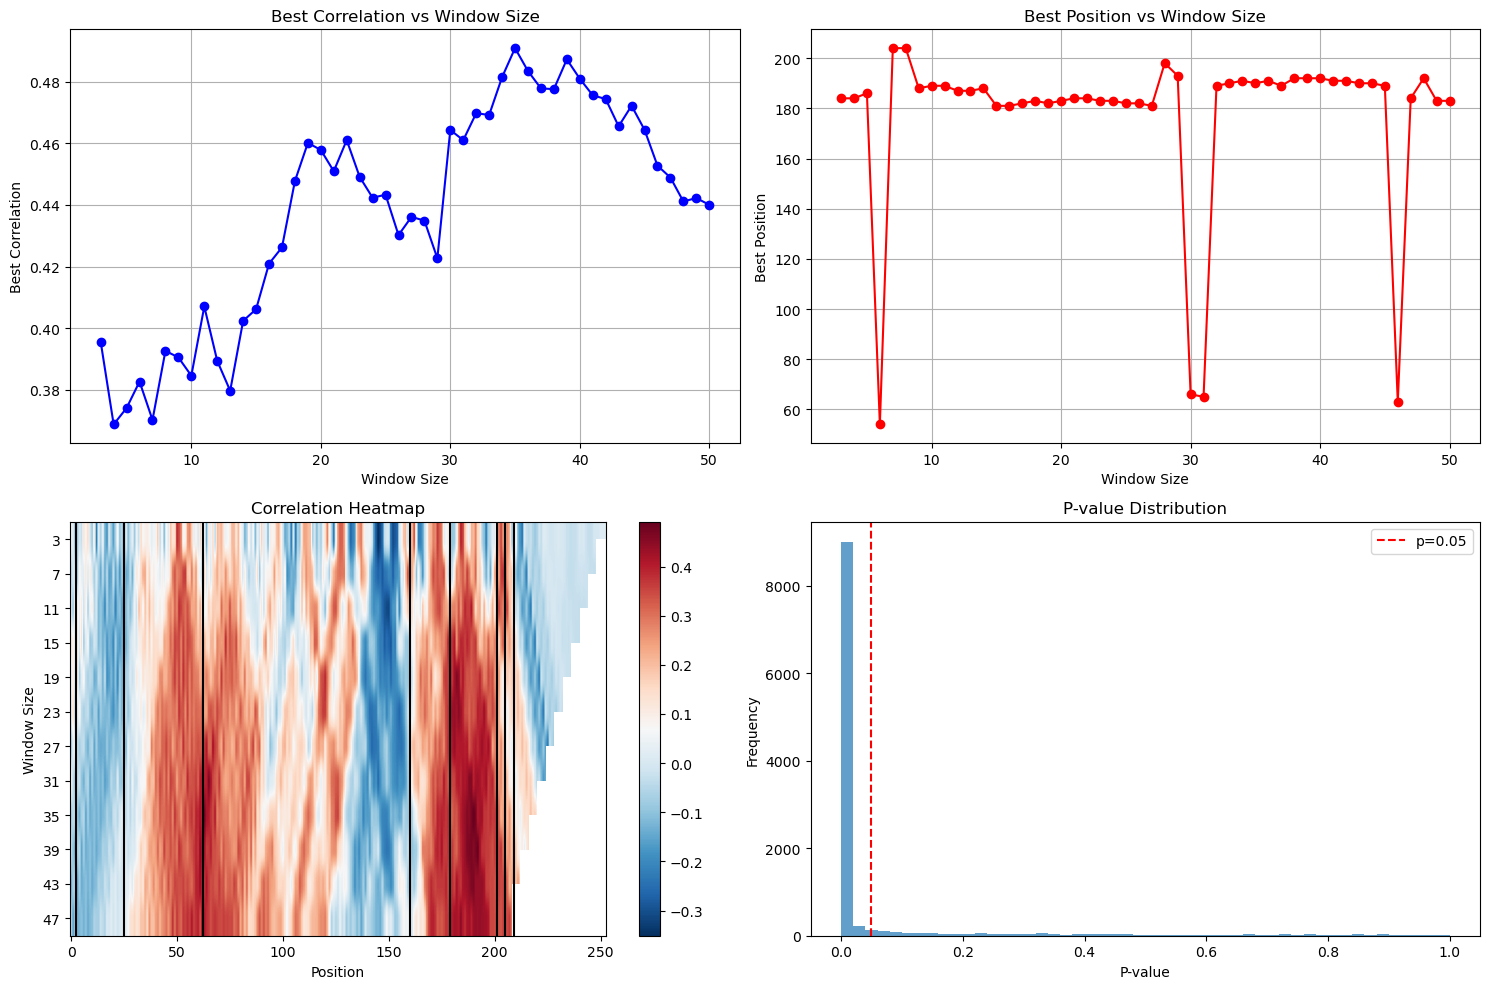

In [33]:
# # Load your data
# sasa_df = pd.read_csv('your_deltasasa_data.csv', index_col=0)  # proteins x residues
# traits = pd.read_csv('your_traits.csv', index_col=0)['trait_column']

# Initialize analyzer
analyzer = SASAWindowAnalyzer(
    sasa_df=test_df.T,
    traits=test_dataset.set_index('uid')['temp'],
    max_window_size=50,  # Adjust based on your protein lengths
    min_window_size=3
)

# Run full analysis
summary = analyzer.run_full_analysis(correlation_method='pearson')

# Get top windows
top_windows = analyzer.get_top_windows(20)
print(top_windows)

# Visualize results
analyzer.plot_results()

# Extract features for modeling
window_features = analyzer.get_window_features(10)

## Starting fresh

In [55]:
import numpy as np
import pandas as pd
from Bio import PDB

In [56]:
## testing out per-residue contributions
from pyrosetta import init, pose_from_pdb, get_score_function
from pyrosetta.rosetta.core.scoring import score_type_from_name


In [71]:
from IPython.display import display, clear_output

In [49]:
def residue_average_contacts(structure_file, chain_id='A', contact_cutoffs=(4.5, 1.5)):
    """
    Compute per-residue average number of atomic contacts for a given protein chain.

    Parameters
    ----------
    structure_file : str
        Path to a PDB file.
    chain_id : str, optional
        Chain identifier (default 'A').
    contact_cutoffs : tuple of float, optional
        Distance cutoffs (in Å) at which to count contacts.

    Returns
    -------
    dict
        Mapping {residue_number: average_contact_count}.
    """
    parser = PDB.PDBParser(QUIET=True)
    struct = parser.get_structure("prot", structure_file)
    
    # collect amino acid residues
    residues = [res for res in PDB.Selection.unfold_entities(struct, 'R') 
                if PDB.Polypeptide.is_aa(res, standard=True)]
    residues_present = sorted([res.id[1] for res in residues])
    residues_range = list(range(residues_present[0], residues_present[-1] + 1))
    residues_absent = set(residues_range) - set(residues_present)
    residues_missing_nbrs = residues_absent.union(
        {residues_range[0], residues_range[-1]},
        {r + 1 for r in residues_absent},
        {r - 1 for r in residues_absent}
    )

    # make a NeighborSearch for the specified chain
    model = struct[0]
    if chain_id not in model:
        raise ValueError(f"Chain {chain_id} not found in {structure_file}")
    chain = model[chain_id]
    atoms = PDB.Selection.unfold_entities(chain, 'A')
    nbr_search = PDB.NeighborSearch(atoms, bucket_size=1000)

    # compute contacts at each cutoff
    contact_counts = {cutoff: {resi: 0 if resi not in residues_absent else np.nan
                               for resi in residues_range}
                      for cutoff in contact_cutoffs}
    for cutoff in contact_cutoffs:
        for (res1, res2) in nbr_search.search_all(cutoff, level='R'):
            if res1.id[1] in contact_counts[cutoff]:
                contact_counts[cutoff][res1.id[1]] += 1
            if res2.id[1] in contact_counts[cutoff]:
                contact_counts[cutoff][res2.id[1]] += 1

    # average across cutoffs
    df = pd.DataFrame(contact_counts)
    df['average_contacts'] = df.mean(axis=1, skipna=True)

    # mask missing residues
    df.loc[list(residues_missing_nbrs), 'average_contacts'] = np.nan

    # return as dictionary
    return df['average_contacts'].to_dict()


In [567]:
from pyrosetta import *
from pyrosetta.teaching import *

In [571]:
init(extra_options='-mute all')

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.Release.python310.ubuntu 2025.41+release.de3cc17d509259e29147a2ed8f2a726d644e7e34 2025-10-06T16:25:46] retrieved from: http://www.pyrosetta.org
[ WARNING ] Resetting the global tracer options, which have already been set.
[ WARNING ] This will not affect Tracers which are already initialized.


In [574]:


def get_fa_terms(pdb, terms=['fa_sol', 'fa_atr', 'fa_elec'], include_ss=True):
    
    # Load your protein structure
    pose = pose_from_pdb(pdb)
    
    # Get the default scorefunction (ref2015 or beta_nov16, etc.)
    scorefxn = get_score_function()
    
    # Score the pose
    scorefxn(pose)
    
    # Extract per-residue energies
    energies = pose.energies()
    result = dict((t, {}) for t in terms)

    # Add secondary structure dictionary if requested
    if include_ss:
        dssp = DsspMover()
        dssp.apply(pose)
        result['secondary_structure'] = {}
        sec_struct = pose.secstruct()  # returns a string of single-letter codes
        # Example: 'HHHCCCCEEE...' (H=helix, E=sheet, L/C=loop)
    
    for i in range(1, pose.total_residue() + 1):
        emap = pose.energies().residue_total_energies(i)
        # res_energy = energies.residue_total_energy(i)
        for term in terms:
            result[term][i] = emap[score_type_from_name(term)]

        if include_ss:
            result['secondary_structure'][i] = sec_struct[i - 1]
            
    clear_output(wait=True)
    return result

In [554]:
import freesasa

def compute_residue_sasa_and_delta(pdb_file):
    """
    Compute per-residue solvent-accessible surface area (SASA) and
    normalized ΔSASA (fractional burial) using FreeSASA.

    Parameters
    ----------
    pdb_file : str
        Path to PDB file.

    Returns
    -------
    dict
        Dictionary mapping residue number → {
            'resname': str,
            'sasa': float,
            'delta_sasa': float,
            'normalized_delta_sasa': float
        }
    """

    # Load structure and compute SASA
    structure = freesasa.Structure(pdb_file)
    result = freesasa.calc(structure)

    # Reference SASA values for fully exposed residues (Å²)
    reference_sasa = {
        'ALA': 129.0, 'ARG': 274.0, 'ASN': 195.0, 'ASP': 193.0,
        'CYS': 167.0, 'GLU': 223.0, 'GLN': 225.0, 'GLY': 104.0,
        'HIS': 224.0, 'ILE': 197.0, 'LEU': 201.0, 'LYS': 236.0,
        'MET': 224.0, 'PHE': 240.0, 'PRO': 159.0, 'SER': 155.0,
        'THR': 172.0, 'TRP': 285.0, 'TYR': 263.0, 'VAL': 174.0
    }

    # Aggregate per-residue SASA
    sasa_by_residue = {}
    for i in range(structure.nAtoms()):
        res_num = structure.residueNumber(i)
        res_name = structure.residueName(i)

        if res_num not in sasa_by_residue:
            sasa_by_residue[res_num] = {'resname': res_name, 'sasa': 0.0}

        sasa_by_residue[res_num]['sasa'] += result.atomArea(i)

    # Compute ΔSASA and normalized ΔSASA
    for res_num, res_data in sasa_by_residue.items():
        res_name = res_data['resname']
        sasa = res_data['sasa']

        if res_name in reference_sasa:
            ref_sasa = reference_sasa[res_name]
            delta = ref_sasa - sasa
            norm_delta = delta / ref_sasa if ref_sasa > 0 else None
        else:
            delta, norm_delta = None, None

        res_data['delta_sasa'] = delta
        res_data['normalized_delta_sasa'] = norm_delta

    return sasa_by_residue


In [37]:
pdbs = glob.glob('./../data/processed_structures/*.pdb')

In [38]:
# Initialize Rosetta
init()

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2025 [Rosetta PyRosetta4.Release.python310.ubuntu 2025.41+release.de3cc17d509259e29147a2ed8f2a726d644e7e34 2025-10-06T16:25:46] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags
core.init: Rosetta version: PyRosetta4.Release.python310.ubuntu r410 2025.41+release.de3cc17d50 de

In [577]:
all_protein_data = []
for i, _pdb in enumerate(pdbs):
    print(i)
    sasa_df = pd.DataFrame(compute_residue_sasa_and_delta(_pdb)).T
    sasa_df.index = [int(i.lstrip(' ').rstrip(' ')) for i in sasa_df.index]
    fa_term_df = pd.DataFrame(get_fa_terms(_pdb))
    
    contact_range = 4.5
    contacts = pd.Series(residue_average_contacts(_pdb, contact_cutoffs=(contact_range,)), name=f'contacts_at_{contact_range}')
    pdb_df = pd.concat([sasa_df, fa_term_df,contacts], axis=1).assign(file=_pdb).rename_axis(index='loc')
    all_protein_data.append(pdb_df)

9340


In [578]:
plotdf = pd.concat(all_protein_data, axis=0).reset_index()

In [579]:
plotdf.head()

,loc,resname,sasa,delta_sasa,normalized_delta_sasa,fa_sol,fa_atr,fa_elec,secondary_structure,contacts_at_4.5,file
0,1,MET,75.315752,148.684248,0.663769,2.886560,-6.134512,-3.269996,L,NaN,./../data/processed_structures/GB_GCA_00105494...
1,2,ARG,41.959943,232.040057,0.846862,7.630707,-9.452707,-6.076714,E,14.0,./../data/processed_structures/GB_GCA_00105494...
2,3,LEU,0.0,201.0,1.0,1.217929,-8.927249,-2.658222,E,16.0,./../data/processed_structures/GB_GCA_00105494...
3,4,VAL,0.125247,173.874753,0.99928,0.905438,-7.462143,-1.721541,E,16.0,./../data/processed_structures/GB_GCA_00105494...
4,5,LEU,3.253464,197.746536,0.983814,0.664696,-8.006336,-1.481625,E,16.0,./../data/processed_structures/GB_GCA_00105494...


In [336]:
# %store plotdf

Stored 'plotdf' (DataFrame)


In [580]:
plotdf['uid'] = plotdf['file'].apply(lambda x: x.split('/')[-1].split('_A')[0])
plotdf = plotdf.drop('file', axis=1).set_index(['uid', 'loc'])

In [581]:
plotdf.to_csv('./../data/metric_tables/20251012_per_residue_data.tsv.gz',
             sep='\t', compression='gzip')

## Try to align residues with alignment residues

In [582]:
from Bio.Data import IUPACData

In [583]:
def check_mapping(msa_fa, mapping, _id, actual_residues, verbose=False, check=True):
    aln_seq = get_seq_from_msa(msa_fa, _id)
    for key, item in mapping.items():
        # account for trailing gaps
        if item is not None:
            o_res, a_res = actual_residues[key], aln_seq[item]
            if verbose:
                print(o_res, a_res)
            if check:
                assert a_res in ['-', o_res],  f'{a_res} to {o_res} @ {key}'

    return True

def get_seq_from_msa(msa_fa, seq_id):
    rec = None
    for r in SeqIO.parse(msa_fa, "fasta"):
        if r.id == seq_id:
            rec = r
            break
    if rec is None:
        raise ValueError(f"Protein {seq_id} not found in MSA")

    aln_seq = str(rec.seq)
    return aln_seq

In [584]:
def map_residues_to_alignment_columns(msa_fasta, protein_id, orig_res):
    """
    Given an MSA fasta and a protein identifier inside it,
    map original residue positions to alignment column indices.

    Parameters
    ----------
    msa_fasta : str
        path to a FoldMason MSA FASTA (AA alignment).
    protein_id : str
        The seq record ID in the MSA file corresponding to this protein.
    orig_res_nums : list[int]
        List of original residue numbers (in order) for that protein.

    Returns
    -------
    dict
        Mapping: original residue number → alignment column index (1-based)
        (or None if gap / not aligned).
    """

    aln_seq = get_seq_from_msa(msa_fasta, protein_id)
    # iterate through alignment sequence, track mapping of ungapped-seq index → alignment column
    mapping = {}
    if len(np.unique([s for s in aln_seq])) < 2:
        print('yes')
        return mapping
    # start at first maintained location in sequence
    first_aln_res = [s for s in aln_seq if s != '-'][0]
    for seq_idx in orig_res.index:
        if orig_res.loc[seq_idx] == first_aln_res:
            break
    
    # seq_idx = index in original (ungapped) sequence
    for aln_col, aa in enumerate(aln_seq, start=0):

        if aa != "-":

            mapping[seq_idx] = aln_col

            seq_idx += 1

            if seq_idx >= orig_res.index.max():
                break
            
        # if we've reached the end of the alignment
        if aln_col+1 > len(aln_seq)-1:
            break

        # if the column was deleted, move until a match is found   
        if (aln_seq[aln_col+1] != '-'):
            while aln_seq[aln_col+1] != orig_res.loc[seq_idx]:
                seq_idx += 1

    # For any original residues not matched (e.g. trailing gaps), map to None
    for res in orig_res.index:
        if res not in mapping:
            mapping[res] = None

    return mapping





In [585]:
# assign an "aligned res" column
msa = './../data/result.fasta_aa_nogap.fa'
idx = pd.IndexSlice

for i, _id in enumerate(list(filtered['uid'].unique())):

    # original locations to residues, for checking
    loc2res = plotdf.loc[idx[_id, :], 'resname'].dropna().map(lambda x: IUPACData.protein_letters_3to1[x.strip().title()]).droplevel(0)
    # og res to alignment res
    mapping = map_residues_to_alignment_columns(msa, f'{_id}_A_processed', loc2res)
    # check every 5 and update progress
    if i % 10 == 0:
        display(i)
        clear_output(wait=True)
    
    check_mapping(msa, mapping, f'{_id}_A_processed', loc2res.to_dict())
        
    # assign new column
    plotdf.loc[idx[_id, :], 'aln_res'] = plotdf.loc[idx[_id, :], :].index.get_level_values(1).map(mapping)

8530

In [586]:
# print(i)

# check_mapping(msa, mapping, f'{_id}_A_processed', loc2res.to_dict(), verbose=True, check=False)

# get_seq_from_msa(msa, f'{_id}_A_processed')

# ''.join(list(loc2res.values))

In [587]:
plotdf.to_csv('./../data/metric_tables/20251012_per_residue_data.tsv.gz',
             sep='\t', compression='gzip')

## plotting (jesus christ finally)

In [588]:
plotdf.head()

resname       sasa  delta_sasa normalized_delta_sasa  \
uid                loc                                                        
GB_GCA_001054945.1 1       MET  75.315752  148.684248              0.663769   
                   2       ARG  41.959943  232.040057              0.846862   
                   3       LEU        0.0       201.0                   1.0   
                   4       VAL   0.125247  173.874753               0.99928   
                   5       LEU   3.253464  197.746536              0.983814   

                          fa_sol    fa_atr   fa_elec secondary_structure  \
uid                loc                                                     
GB_GCA_001054945.1 1    2.886560 -6.134512 -3.269996                   L   
                   2    7.630707 -9.452707 -6.076714                   E   
                   3    1.217929 -8.927249 -2.658222                   E   
                   4    0.905438 -7.462143 -1.721541                   E   
                   5    0.664696 -8.006336 -1.481625                   E   

                        contacts_at_4.5  aln_res  
uid                loc                            
GB_GCA_001054945.1 1                NaN      1.0  
                   2               14.0      2.0  
                   3               16.0      3.0  
                   4               16.0      4.0  
                   5               16.0      5.0

In [589]:
plotdf['temp'] = plotdf.index.get_level_values(0).map(filtered.set_index('uid')['temp'].to_dict())

In [590]:
plotdf.head()

resname       sasa  delta_sasa normalized_delta_sasa  \
uid                loc                                                        
GB_GCA_001054945.1 1       MET  75.315752  148.684248              0.663769   
                   2       ARG  41.959943  232.040057              0.846862   
                   3       LEU        0.0       201.0                   1.0   
                   4       VAL   0.125247  173.874753               0.99928   
                   5       LEU   3.253464  197.746536              0.983814   

                          fa_sol    fa_atr   fa_elec secondary_structure  \
uid                loc                                                     
GB_GCA_001054945.1 1    2.886560 -6.134512 -3.269996                   L   
                   2    7.630707 -9.452707 -6.076714                   E   
                   3    1.217929 -8.927249 -2.658222                   E   
                   4    0.905438 -7.462143 -1.721541                   E   
                   5    0.664696 -8.006336 -1.481625                   E   

                        contacts_at_4.5  aln_res  temp  
uid                loc                                  
GB_GCA_001054945.1 1                NaN      1.0  37.0  
                   2               14.0      2.0  37.0  
                   3               16.0      3.0  37.0  
                   4               16.0      4.0  37.0  
                   5               16.0      5.0  37.0

In [591]:
import matplotlib as mpl
from matplotlib.collections import LineCollection

In [783]:
conserved_residues = (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)

In [604]:
therm_data = plotdf[plotdf['temp'] > 40]
meso_data = plotdf[(plotdf['temp'] < 40) & (plotdf['temp'] > 20)]
psychro_data = plotdf[(plotdf['temp'] < 20)]

In [747]:
drop_cols = ['uid', 'resname', 'loc', 'temp', 'secondary_structure', 'delta_sasa']
single_plot_data1 = therm_data.reset_index().dropna(axis=0).drop(drop_cols, axis=1).groupby('aln_res').mean()
single_plot_data2 = meso_data.reset_index().dropna(axis=0).drop(drop_cols, axis=1).groupby('aln_res').mean()

In [820]:
# bcs = pd.read_csv('./../class_project/data/csubst_analysis/csubst_newhot/branch_convergent_sites.tsv', sep='\t', index_col=0)
# bcs[bcs.site.eq(62)]
contrast_data = single_plot_data1 - single_plot_data2

contrast_data = contrast_data.reset_index()

# contrast_data = contrast_data.mask(~contrast_data['aln_res'].isin(conserved_residues[conserved_residues].index))

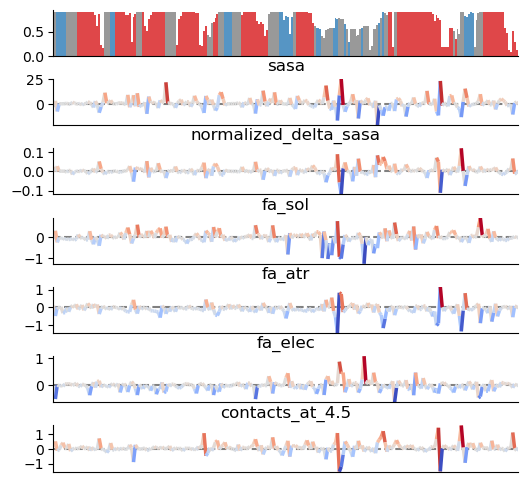

In [848]:
fig = plt.figure(figsize=(6,6))

 #.stack().reset_index().rename(columns={'level_1':'stat', 0:'value'})

ax1 = fig.add_subplot(7,1,1)
ax1.bar(grouped['aln_res'], (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique())).sort_index(),
       color=grouped['ss_color'], width=1, alpha=0.8, zorder=1)

i = 2
for col in contrast_data.drop('aln_res', axis=1).columns:
    ax = fig.add_subplot(7,1,i, sharex=ax1)
    
    ax.axhline(0, color='gray', linestyle='--', zorder=0)
            
    x = contrast_data['aln_res']
    y = contrast_data.set_index('aln_res')[col] * (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()))
    y_smooth = y.rolling(window=1, center=True).mean()
    
    # Plotting
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=y_smooth.min(), vmax=y_smooth.max())
    colors = y_smooth.apply(norm).map(mpl.colormaps['coolwarm']).apply(mpl.colors.to_hex).values
    
    # Build segments for LineCollection
    points = np.array([x, y_smooth]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Normalize and color map
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=y_smooth.min(), vmax=y_smooth.max())
    lc = LineCollection(
        segments,
        cmap='coolwarm',
        norm=norm,
        linewidth=2.5
    )
    lc.set_array(y_smooth.values)
    ax.add_collection(lc)
    
    # plt.scatter(x, y_smooth, label='Smoothed Curve (Spline)', c=colors, s=3)    
    sns.despine()
    ax.set_title(col)
    ax.set_xlabel('')
    # ax.set_ylabel(col, rotation=0, )
    

        # Adjust limits
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y_smooth.min(), y_smooth.max())
    
    if i != 6:
        ax.set_xticks([])


    i += 1
    
fig.subplots_adjust(hspace=0.5)

In [851]:
import pickle

In [852]:
epoch_losses = []
for _eval in glob.glob('./../data/esm_msa/*_evaluation.pickle'):
    with open(_eval, 'rb') as handle:
        eval_df = pickle.load(handle)
        epoch_losses.append(eval_df['MSE'])

In [861]:
for _eval in glob.glob('./../data/esm_msa/epoch30_evaluation.pickle'):
    with open(_eval, 'rb') as handle:
        eval_df = pd.DataFrame(pickle.load(handle))
        

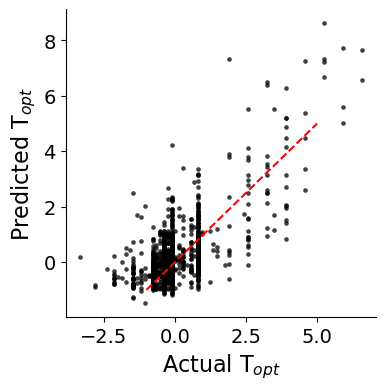

In [862]:
# accuracy plot
fig, ax = plt.subplots(figsize=(4,4))
sns.scatterplot(x=[i.numpy().item() for i in eval_df['y_true']],
y=[i.numpy().item() for i in eval_df['y_pred']], 
               linewidth=0, alpha=0.75, s=11, color='k')
sns.despine()
plt.plot((-1, 5), (-1, 5), color='r', linestyle='--')
plt.tick_params(labelsize=14)
ax.set_ylabel('Predicted T$_{opt}$', fontsize=16)
ax.set_xlabel('Actual T$_{opt}$', fontsize=16)
plt.savefig('./../data/figures/MSA_model_accuracy.png', dpi=400, bbox_inches='tight')

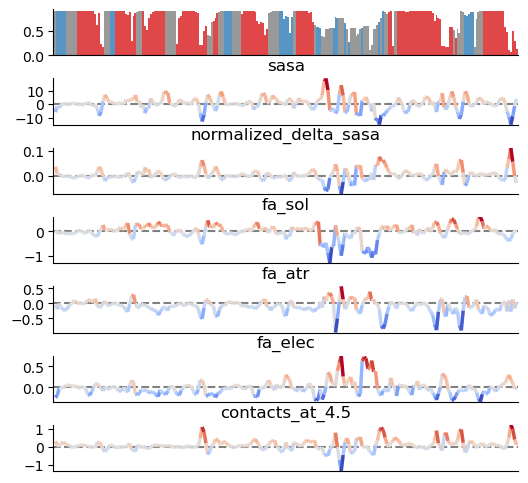

In [849]:
fig = plt.figure(figsize=(6,6))

 #.stack().reset_index().rename(columns={'level_1':'stat', 0:'value'})

ax1 = fig.add_subplot(7,1,1)
ax1.bar(grouped['aln_res'], (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique())).sort_index(),
       color=grouped['ss_color'], width=1, alpha=0.8, zorder=1)

i = 2
for col in contrast_data.drop('aln_res', axis=1).columns:
    ax = fig.add_subplot(7,1,i, sharex=ax1)
    
    ax.axhline(0, color='gray', linestyle='--', zorder=0)
            
    x = contrast_data['aln_res']
    y=contrast_data.set_index('aln_res')[col] # * (plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()))
    y_smooth = y.rolling(window=3, center=True).mean()
    
    # Plotting
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=y_smooth.min(), vmax=y_smooth.max())
    colors = y_smooth.apply(norm).map(mpl.colormaps['coolwarm']).apply(mpl.colors.to_hex).values
    
    # Build segments for LineCollection
    points = np.array([x, y_smooth]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Normalize and color map
    norm = mpl.colors.TwoSlopeNorm(vcenter=0, vmin=y_smooth.min(), vmax=y_smooth.max())
    lc = LineCollection(
        segments,
        cmap='coolwarm',
        norm=norm,
        linewidth=2.5
    )
    lc.set_array(y_smooth.values)
    ax.add_collection(lc)
    
    # plt.scatter(x, y_smooth, label='Smoothed Curve (Spline)', c=colors, s=3)    
    sns.despine()
    ax.set_title(col)
    ax.set_xlabel('')
    # ax.set_ylabel(col, rotation=0, )
    

        # Adjust limits
    ax.set_xlim(x.min(), x.max())
    ax.set_ylim(y_smooth.min(), y_smooth.max())
    
    if i != 6:
        ax.set_xticks([])


    i += 1
    
fig.subplots_adjust(hspace=0.5)

In [835]:
plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()).sort_index()

AttributeError: 'int' object has no attribute 'sort_index'

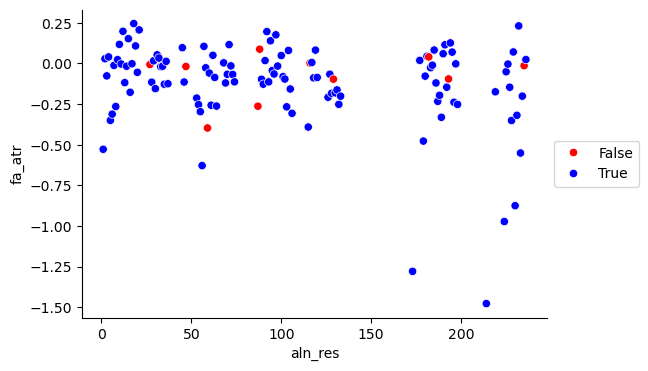

In [811]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=contrast_data.mask(~contrast_data['aln_res'].isin(conserved_residues[conserved_residues].index)),
                x='aln_res', 
                y='fa_atr', 
                hue=single_plot_data1['sasa'] < 100, palette=['r', 'b'])
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

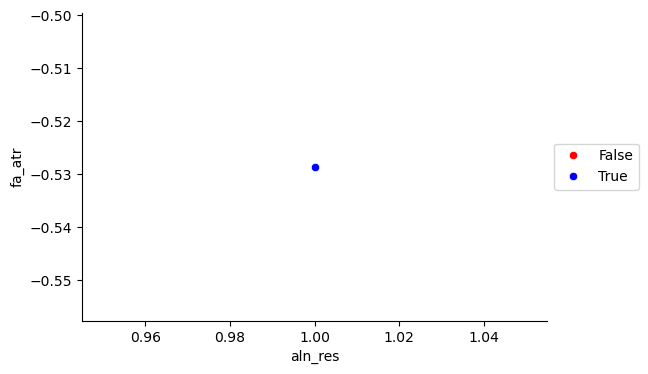

In [807]:
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=contrast_data.mask(~contrast_data['aln_res'].isin(conserved_residues[conserved_residues])),
                x='aln_res', 
                y='fa_atr', 
                hue=single_plot_data1['sasa'] < 100, palette=['r', 'b'])
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

In [770]:


# ---- Aggregate per aligned residue ----
grouped = plotdf.groupby('aln_res').agg({
    'delta_sasa': 'mean',
    'secondary_structure': lambda x: x.value_counts().idxmax()  # modal SS
}).reset_index()

# Map secondary structure to colors
ss_color_map = {'H': '#d7191c',  # Helix - red
                'E': '#2c7bb6',  # Sheet - blue
                'C': '#fdae61'}  # Coil/other - orange

grouped['ss_color'] = grouped['secondary_structure'].map(ss_color_map).fillna('gray')


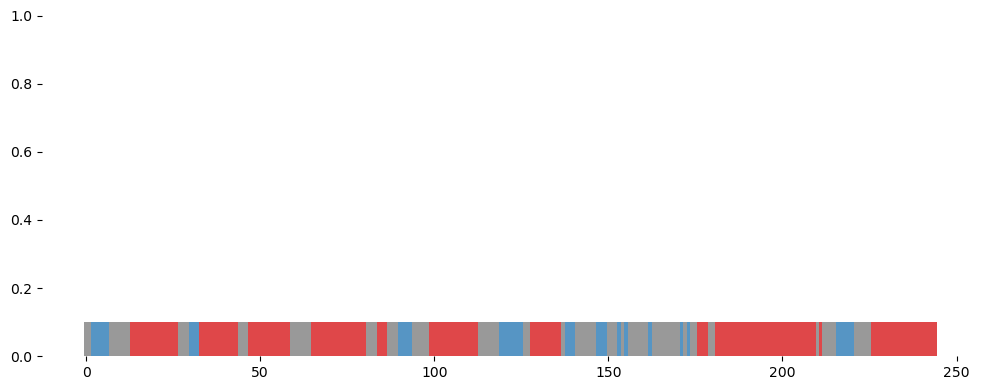

In [830]:

fig, ax = plt.subplots(figsize=(10, 4))

# # Background: domain blocks
# domains = [
#     (1, 29, 'gray'),
#     (30, 67, 'yellow'),
#     (68, 117, 'gray'),
#     (118, 160, 'green'),
#     (161, 214, 'gray')
# ]
# for start, end, color in domains:
#     ax.axvspan(start, end, color=color, alpha=0.25, zorder=0)

# # Plot ΔSASA (continuous feature)
# ax.plot(grouped['aln_res'], grouped['delta_sasa'],
#         color='black', lw=1.5, label='Avg ΔSASA', zorder=2)

# Overlay secondary structure as a colored bar
ax.bar(grouped['aln_res'], 0.1,
       color=grouped['ss_color'], width=1, alpha=0.8, zorder=1)

# # ---- Aesthetic adjustments ----
# ax.set_xlabel("Aligned residue position")
# ax.set_ylabel("ΔSASA (avg)")
# ax.set_xlim(grouped['aln_res'].min(), grouped['aln_res'].max())
# ax.set_title("Residue-level structural map")

# # Legend for secondary structure
# handles = [plt.Line2D([0], [0], color=c, lw=6, label=ss)
#            for ss, c in ss_color_map.items()]
# ax.legend(handles=handles, title="Secondary structure", loc='upper right')

sns.despine(left=True, bottom=True)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [826]:
grouped

,aln_res,delta_sasa,secondary_structure,ss_color
0,0.0,96.777897,L,gray
1,1.0,159.432113,L,gray
2,2.0,206.919113,E,#2c7bb6
3,3.0,197.237535,E,#2c7bb6
4,4.0,189.541583,E,#2c7bb6
...,...,...,...,...
240,240.0,110.362447,H,#d7191c
241,241.0,148.03622,H,#d7191c
242,242.0,101.222732,H,#d7191c
243,243.0,100.01741,H,#d7191c


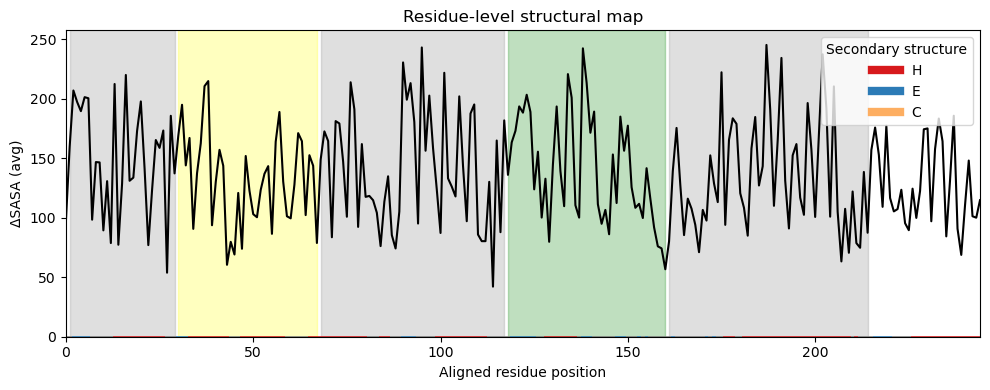

In [769]:
plot_residue_map(plotdf)

/tmp/ipykernel_1597161/3828832729.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=contrast_data.reset_index(),
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


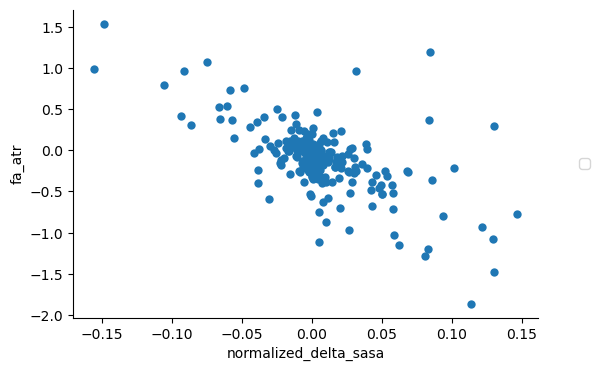

In [750]:
fig,ax = plt.subplots(figsize=(6,4))
sns.scatterplot(data=contrast_data.reset_index(),
            x='normalized_delta_sasa',
            y='fa_atr', 
            # hue='temp', 
            palette='bwr', linewidth=0)
lgd = ax.legend(loc='center', bbox_to_anchor=(1.1, 0.5))
sns.despine()

<Axes: xlabel='fa_elec', ylabel='normalized_delta_sasa'>

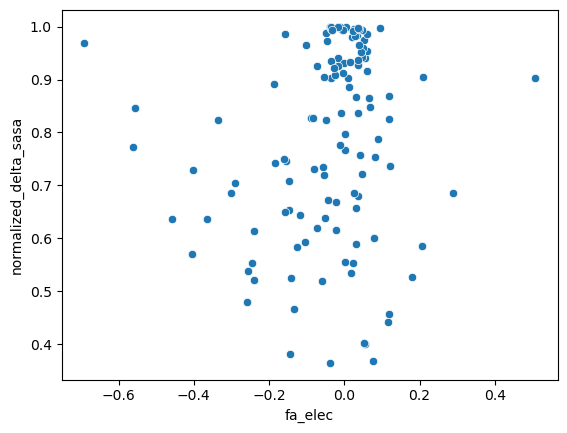

In [762]:
sns.scatterplot(x=single_plot_data1['fa_elec'] - single_plot_data2['fa_elec'], 
                y=single_plot_data1['normalized_delta_sasa'].mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)), 
                )
# sns.histplot(single_plot_data2['fa_atr'], palette=['Prefs'])

<Axes: xlabel='fa_atr', ylabel='normalized_delta_sasa'>

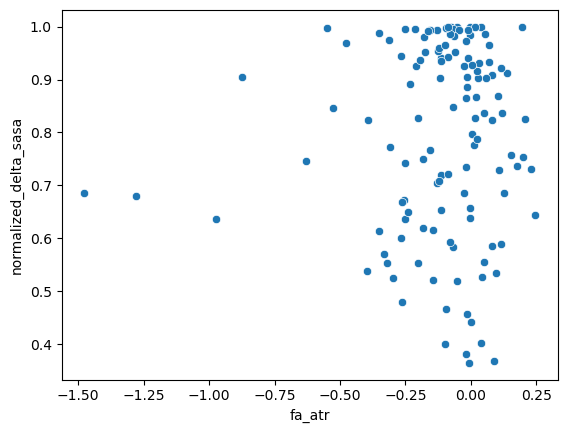

In [752]:
sns.scatterplot(x=single_plot_data1['fa_atr'] - single_plot_data2['fa_atr'], 
                y=single_plot_data1['normalized_delta_sasa'].mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)), 
                )

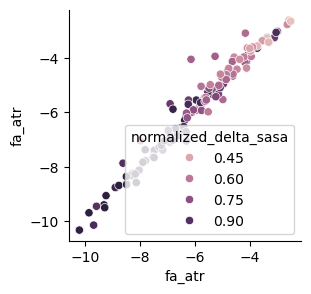

In [744]:
fig, ax = plt.subplots(figsize=(3,3))
sns.scatterplot(x=single_plot_data1['fa_atr'],
                y=single_plot_data2['fa_atr'].mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)), hue=single_plot_data1['normalized_delta_sasa']
                )
sns.despine()
# plt.plot((0, 100), (0, 100))

In [757]:
means = plotdf.reset_index().groupby(['uid', 'aln_res'])['fa_atr'].first().unstack().mean()
conserved_residues = plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90

<Axes: xlabel='0', ylabel='temp'>

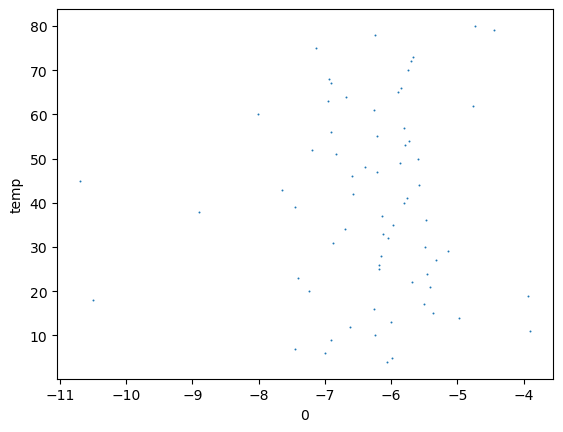

In [760]:
bias_df = (plotdf.reset_index().groupby(['temp', 'aln_res'])['fa_atr'].first().unstack()).stack().reset_index()
sns.scatterplot(data=bias_df[bias_df['aln_res'].isin(conserved_residues[conserved_residues])],
                x=0, y='temp', 
               linewidth=0, s=2)#.mean(1)

In [759]:
bias_df

,temp,aln_res,0
0,4.0,1.0,0.152640
1,4.0,2.0,-0.007013
2,4.0,3.0,-0.748980
3,4.0,4.0,-1.010692
4,4.0,5.0,0.472655
...,...,...,...
15977,80.0,237.0,-0.479290
15978,80.0,238.0,0.105794
15979,80.0,241.0,-0.408286
15980,80.0,242.0,1.565395


<Axes: xlabel='fa_atr', ylabel='Count'>

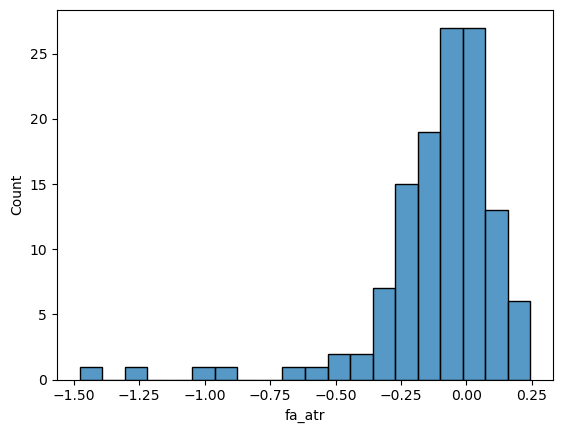

In [703]:
sns.histplot((single_plot_data1['fa_atr'] - single_plot_data2['fa_atr']).mask(~(plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90)))

<Axes: xlabel='fa_atr', ylabel='normalized_delta_sasa'>

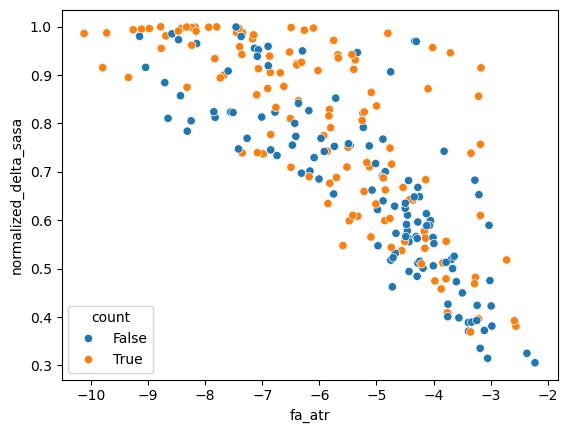

In [697]:
sns.scatterplot(x=single_plot_data2['fa_atr'], 
                y=single_plot_data2['normalized_delta_sasa'], 
                hue=plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique()) > 0.90
                )

<Axes: xlabel='None', ylabel='temp'>

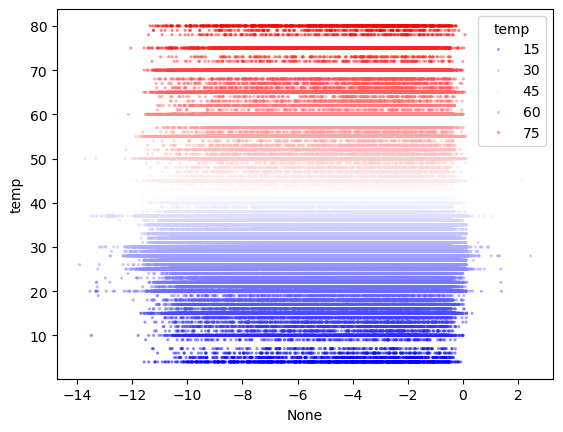

In [666]:
sns.scatterplot(data=plotdf,
                x=plotdf['fa_atr'], 
                y=plotdf['temp'],
                hue='temp', palette='bwr',
                linewidth=0, alpha=0.5,s=5)

In [694]:
plotdf['aln_res'].value_counts() / len(plotdf.index.get_level_values(0).unique())

aln_res
192.0    0.908789
92.0     0.908682
128.0    0.908682
131.0    0.908682
130.0    0.908682
           ...   
243.0    0.120972
166.0    0.120009
239.0    0.112515
240.0    0.070121
244.0    0.050423
Name: count, Length: 245, dtype: float64

In [667]:
import numpy as np
import pandas as pd

# Simulate 10 observations per group
np.random.seed(0)
S1_A = np.random.normal(10, 2, 10)
S1_B = np.random.normal(8, 2, 10)

S2_A = np.random.normal(50, 5, 10)
S2_B = np.random.normal(48, 5, 10)

# Original statistics as DataFrame
df = pd.DataFrame({
    'S1_A': S1_A, 'S1_B': S1_B,
    'S2_A': S2_A, 'S2_B': S2_B
})

# Compute deltas (differences between groups)
df['Delta1'] = df['S1_A'] - df['S1_B']
df['Delta2'] = df['S2_A'] - df['S2_B']

# Check correlation
print("Correlation of deltas:", df[['Delta1','Delta2']].corr().iloc[0,1])


Correlation of deltas: 0.2635810841081134


<Axes: xlabel='S1_A', ylabel='Delta2'>

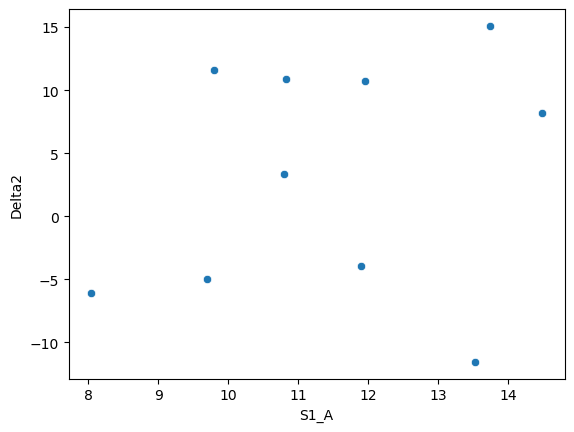

In [669]:
sns.scatterplot(data=df, x='S1_A', y='Delta2')

In [629]:
contrast_data

,sasa,normalized_delta_sasa,fa_sol,fa_atr,fa_elec,contacts_at_4.5
aln_res,,,,,,
0.0,-12.318503,0.084033,-0.308535,0.367806,-0.174204,0.501727
1.0,3.152234,-0.001478,0.352078,-0.528585,-0.557365,0.550216
2.0,-8.705963,0.028762,-0.261337,0.028570,0.010784,-0.144815
3.0,0.045087,-0.000156,-0.011405,-0.076931,-0.038152,-0.071894
4.0,-0.071839,0.000381,-0.061521,0.039837,0.003386,0.258642
...,...,...,...,...,...,...
240.0,-8.080449,0.084546,-0.420290,1.196924,0.340203,0.749520
241.0,-21.587485,0.129337,-0.067266,-1.081668,-0.183400,2.183638
242.0,2.884839,-0.04389,0.171441,0.277361,0.146857,0.073300


In [552]:
plotdf.reset_index().groupby(aln_res)

,uid,loc,resname,sasa,delta_sasa,fa_sol,fa_atr,fa_elec,contacts_at_4.5,aln_res,temp
0,GB_GCA_001054945.1,1,MET,75.315752,148.684248,2.886560,-6.134512,-3.269996,NaN,1.0,37.0
1,GB_GCA_001054945.1,2,ARG,41.959943,232.040057,7.630707,-9.452707,-6.076714,14.0,2.0,37.0
2,GB_GCA_001054945.1,3,LEU,0.0,201.0,1.217929,-8.927249,-2.658222,16.0,3.0,37.0
3,GB_GCA_001054945.1,4,VAL,0.125247,173.874753,0.905438,-7.462143,-1.721541,16.0,4.0,37.0
4,GB_GCA_001054945.1,5,LEU,3.253464,197.746536,0.664696,-8.006336,-1.481625,16.0,5.0,37.0
...,...,...,...,...,...,...,...,...,...,...,...
1981284,RS_GCF_902813185.1,217,PHE,47.086568,192.913432,3.579789,-7.978523,-2.024430,13.0,234.0,29.0
1981285,RS_GCF_902813185.1,218,ALA,78.598081,50.401919,2.903390,-3.071718,-0.572729,8.0,235.0,29.0
1981286,RS_GCF_902813185.1,219,ALA,20.561147,108.438853,2.095144,-4.238664,-1.296362,11.0,236.0,29.0
1981287,RS_GCF_902813185.1,220,LEU,4.226527,196.773473,0.301588,-7.131935,-0.986823,14.0,241.0,29.0


In [538]:
mpl.colors.TwoSlopeNorm()

aln_res
0.0                                   (0.0, 0.0, 0.0, 0.0)
1.0                                   (0.0, 0.0, 0.0, 0.0)
2.0                                   (0.0, 0.0, 0.0, 0.0)
3.0                                   (0.0, 0.0, 0.0, 0.0)
4.0                                   (0.0, 0.0, 0.0, 0.0)
                               ...                        
240.0    (0.7338977872549018, 0.8200178787647059, 0.970...
241.0                                 (0.0, 0.0, 0.0, 0.0)
242.0                                 (0.0, 0.0, 0.0, 0.0)
243.0                                 (0.0, 0.0, 0.0, 0.0)
244.0                                 (0.0, 0.0, 0.0, 0.0)
Name: sasa, Length: 245, dtype: object

In [513]:
'MINLVLFGKPGAGKGTQADVLKEKY--NLKHISTGDVFRYNI-KNGTEL-GKLAKSFMDRGDLVPDE-VTIDMLKEEV----EKNPDAAGFIFDGFPRTT-QAEALDNFLGSK-DMEINATIALE-ADDNILVARLLE------------RGKLSG-------------------RTDDQDEGKIRNRFDEYNQKTAPLKAYYE-------KQ-GKFHSVN-GIGEISEISERLGAVVDT'.index('RLLE')

134

In [511]:
contast_data

,sasa,delta_sasa,fa_sol,fa_atr,fa_elec,contacts_at_4.5
aln_res,,,,,,
0.0,-12.318503,2.016489,-0.308535,0.367806,-0.174204,0.501727
1.0,3.152234,13.245593,0.352078,-0.528585,-0.557365,0.550216
2.0,-8.705963,-6.51179,-0.261337,0.028570,0.010784,-0.144815
3.0,0.045087,-0.821502,-0.011405,-0.076931,-0.038152,-0.071894
4.0,-0.071839,-1.808757,-0.061521,0.039837,0.003386,0.258642
...,...,...,...,...,...,...
240.0,-8.080449,16.10668,-0.420290,1.196924,0.340203,0.749520
241.0,-21.587485,26.148901,-0.067266,-1.081668,-0.183400,2.183638
242.0,2.884839,-12.834593,0.171441,0.277361,0.146857,0.073300


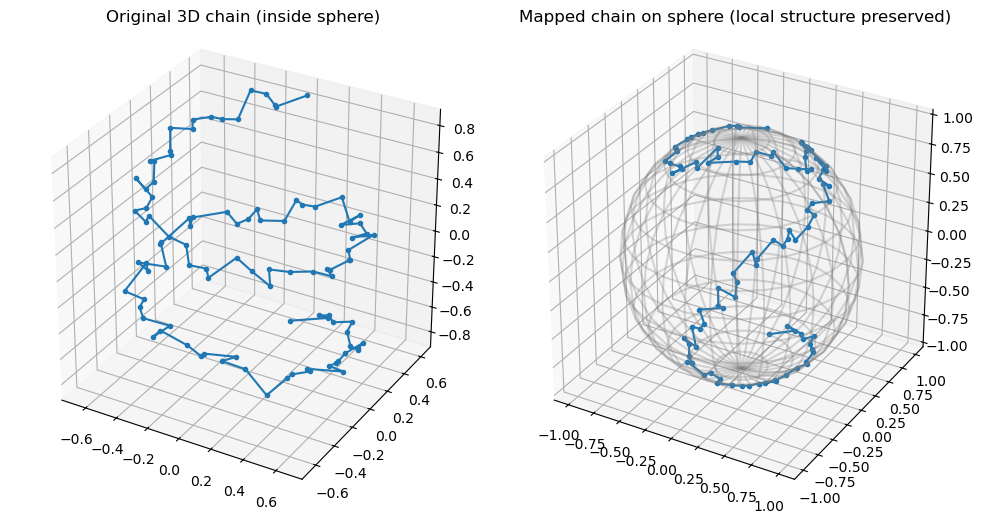

In [763]:
# Spherical MDS example: map 3D chain to sphere while preserving local structure
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# -----------------------
# Helper functions
# -----------------------
def spherical_geodesic_angle(x, y):
    cosang = np.dot(x, y) / (np.linalg.norm(x)*np.linalg.norm(y))
    cosang = np.clip(cosang, -1.0, 1.0)
    return np.arccos(cosang)

def angles_to_xyz(thetas, phis, R=1.0):
    x = R * np.column_stack((
        np.sin(thetas)*np.cos(phis),
        np.sin(thetas)*np.sin(phis),
        np.cos(thetas)
    ))
    return x

def stress_from_angles(vars, D, W, R=1.0):
    n = D.shape[0]
    thetas = vars[:n]
    phis   = vars[n:]
    X = angles_to_xyz(thetas, phis, R)
    XX = X @ X.T
    norms = np.linalg.norm(X, axis=1)
    cosang = np.clip(XX / np.outer(norms, norms), -1, 1)
    Ang = np.arccos(cosang)
    S = (W * (D - R*Ang)**2).sum()
    return S

# -----------------------
# Generate a test 3D chain
# -----------------------
n = 100
t = np.linspace(0, 4*np.pi, n)
p = np.column_stack((0.6*np.sin(t), 0.6*np.cos(t), np.linspace(-0.8,0.8,n)))
p += 0.05 * np.random.randn(*p.shape)  # small noise

R = 1.0

# -----------------------
# Build distance matrix and weights
# -----------------------
D = np.linalg.norm(p[:,None,:] - p[None,:,:], axis=2)
W = np.zeros_like(D)
k = 8  # local neighborhood size
for i in range(n):
    nn = np.argsort(D[i])[:k+1]
    W[i, nn] = 1
W = (W + W.T)/2.0

# -----------------------
# Initialize by radial projection
# -----------------------
init_X = R * (p / np.linalg.norm(p, axis=1)[:,None])
thetas = np.arccos(init_X[:,2]/R)
phis = np.arctan2(init_X[:,1], init_X[:,0])
vars0 = np.concatenate([thetas, phis])

# -----------------------
# Optimize on the sphere
# -----------------------
res = minimize(stress_from_angles, vars0, args=(D, W, R),
               method='L-BFGS-B', options={'maxiter': 400, 'disp': True})
thetas_opt = res.x[:n]
phis_opt = res.x[n:]
Q = angles_to_xyz(thetas_opt, phis_opt, R)

# -----------------------
# Plot original vs spherical layout
# -----------------------
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Original chain inside sphere
ax1.plot(p[:,0], p[:,1], p[:,2], '-o', ms=3)
ax1.set_title("Original 3D chain (inside sphere)")
ax1.set_box_aspect([1,1,1])

# Optimized positions on sphere
ax2.plot(Q[:,0], Q[:,1], Q[:,2], '-o', ms=3)
# draw sphere surface (for reference)
u, v = np.mgrid[0:2*np.pi:30j, 0:np.pi:15j]
x = np.cos(u)*np.sin(v)
y = np.sin(u)*np.sin(v)
z = np.cos(v)
ax2.plot_wireframe(x, y, z, color='gray', alpha=0.3)
ax2.set_title("Mapped chain on sphere (local structure preserved)")
ax2.set_box_aspect([1,1,1])

plt.tight_layout()
plt.show()


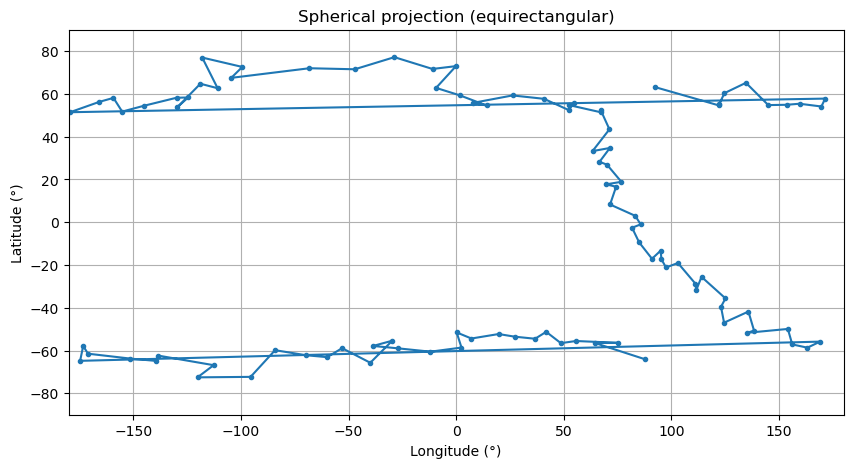

In [764]:
# --- 2D map of spherical layout (continuing from previous code) ---
# Convert optimized 3D points Q to spherical angles
R = np.linalg.norm(Q[0])  # radius (should be 1)
phis = np.arctan2(Q[:,1], Q[:,0])        # longitude in [-pi, pi]
thetas = np.arccos(Q[:,2] / R)           # colatitude [0, pi]
lats = np.pi/2 - thetas                  # latitude [-pi/2, pi/2]

# --- Equirectangular projection ---
x = np.degrees(phis)
y = np.degrees(lats)

plt.figure(figsize=(10,5))
plt.plot(x, y, '-o', ms=3)
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.title("Spherical projection (equirectangular)")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.grid(True)
plt.show()


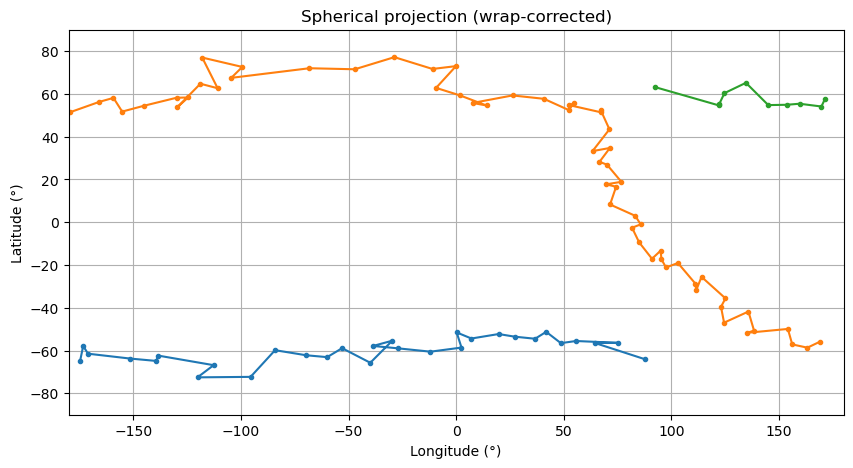

In [765]:
# Handle wrap-around at ±180°
dx = np.diff(x)
wrap_points = np.where(np.abs(dx) > 180)[0]
segments = np.split(np.arange(len(x)), wrap_points + 1)

plt.figure(figsize=(10,5))
for seg in segments:
    plt.plot(x[seg], y[seg], '-o', ms=3)
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.title("Spherical projection (wrap-corrected)")
plt.xlim(-180, 180)
plt.ylim(-90, 90)
plt.grid(True)
plt.show()
